### 3)  Illustration of Markov's, Chebyshev's and Hoeffding's Inequalities (25 points)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import scienceplots 
plt.style.use(["science", "grid"])
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
})

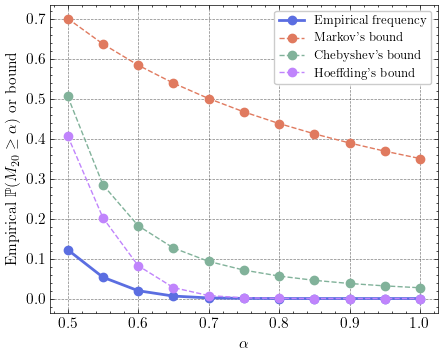

In [4]:
# set seed
rng = np.random.default_rng(seed=30)

p = 0.35 # Bernoulli parameter
Nx = 20 # number of random variables
n  = 1_000_000 # number of repetetions

# draw n samples of Nx independent Bernoulli variables 
X  = rng.uniform(low=0, high=1, size=(n, Nx)) <= p
SX = X.sum(axis=1)

# allocate space for results
alphas = np.linspace(0.5, 1.0, 11)
freq_SX_geq   = np.zeros(len(alphas))
theory_bounds = np.zeros((len(alphas),3))

# loop over each alpha, and calculate the conditions
for j, alpha in enumerate(alphas):

    # 1) Empirical frequency of observing S_20 larger than alpha
    SX_geq = SX / 20.0 >= alpha
    freq_SX_geq[j] = SX_geq.mean()
    
    # 3) Markow's bound
    theory_bounds[j,0] = p / alpha

    # 4) Chebyshev's bound
    theory_bounds[j,1] = p * (1 - p) / (Nx*(alpha - p)**2)

    # 5) Hoeffding's bound
    theory_bounds[j,2] = np.exp(- 40*(alpha-p)**2)


# plot the empirical frequency and the corresponding bounds
plt.figure(figsize=(5, 4))

plt.plot(
    alphas, freq_SX_geq,
    marker="o", color="#5B6EE1", lw="2",
    label="Empirical frequency"
)

colors = ["#E07A5F", "#81B29A", "#C084FC"]
bound_labels = ["Markov's bound", "Chebyshev's bound", "Hoeffding's bound"]

for i, (color, label) in enumerate(zip(colors, bound_labels)):
    plt.plot(
        alphas, theory_bounds[:, i],
        marker="o", color=color, ls="--",
        label=label
    )

plt.xlabel(r"$\alpha$")
plt.ylabel(r"Empirical $\mathbb{P}(M_{20}\geq \alpha)$ or bound")
plt.legend()
plt.savefig("output/bound_plot.png",dpi=300)
plt.show()